In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Dataset transformations
from torchvision.transforms import AutoAugment, AutoAugmentPolicy

batch_size = 96
# AutoAugment and better scaling
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    AutoAugment(AutoAugmentPolicy.IMAGENET),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [3]:
# Simple label smoothing loss
import torch.nn as nn

class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        
    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        logprobs = torch.log_softmax(pred, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [4]:
from torch.utils.data import random_split, DataLoader

print(" Loading Stanford Dogs dataset...")

# Stanford Dogs datasets with validation split
full_dataset = torchvision.datasets.ImageFolder(
    root='../Images',
    transform=transform
)

print(f" Total samples: {len(full_dataset)}")
print(f" Number of classes: {len(full_dataset.classes)}")

# Define split sizes (e.g., 80% train, 20% val)
val_percent = 0.2
val_size = int(len(full_dataset) * val_percent)
train_size = len(full_dataset) - val_size

print(f" Train/Val split: {train_size}/{val_size} samples")

# Create train/val splits
trainset, valset = random_split(full_dataset, [train_size, val_size])

# Create simple DataLoaders
trainloader = DataLoader(
    trainset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    valset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True
)

classes = full_dataset.classes
print(f" Dataset loaded with {len(classes)} classes and standard DataLoaders")

 Loading Stanford Dogs dataset...
 Total samples: 20580
 Number of classes: 120
 Train/Val split: 16464/4116 samples
 Dataset loaded with 120 classes and standard DataLoaders


In [5]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

In [6]:
# Convolutional Neural Network (CNN) model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ResNet101 model for dog breed classification
import torchvision.models as models
device = torch.device('cuda')
net = models.resnet101(weights='IMAGENET1K_V1')
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, 120)
net = net.to(device)

# Simple loss and optimizer
criterion = LabelSmoothingLoss(smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=0.0005, weight_decay=1e-4)

print("Your network is ready for training!")

Your network is ready for training!


In [7]:
# Label Smoothing Loss for better accuracy
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        logprobs = torch.log_softmax(pred, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

import torchvision.models as models
device = torch.device('cuda')
net = models.resnet101(weights='IMAGENET1K_V1')
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, 120)
net = net.to(device)

optimizer = optim.AdamW(net.parameters(), lr=0.0003, weight_decay=1e-4)  # Slightly lower LR for stability

print("Your network is ready for training!")

Your network is ready for training!


In [8]:
# Simple Test Time Augmentation (TTA) for accuracy boost
def test_time_augmentation_batch(model, images, num_augmentations=3):
    """Apply simple TTA to a batch of images"""
    model.eval()
    batch_size = images.size(0)
    
    # Store all predictions
    all_predictions = []
    
    # Original images
    with torch.no_grad():
        outputs = model(images)
        all_predictions.append(torch.softmax(outputs, dim=1))
    
    # Simple augmented versions
    for _ in range(num_augmentations):
        # Apply simple horizontal flip augmentation
        aug_images = images.clone()
        
        # Random horizontal flip for each image independently
        for i in range(batch_size):
            if torch.rand(1) > 0.5:
                aug_images[i] = torch.flip(aug_images[i], dims=[2])
        
        with torch.no_grad():
            outputs = model(aug_images)
            all_predictions.append(torch.softmax(outputs, dim=1))
    
    # Average all predictions
    avg_predictions = torch.mean(torch.stack(all_predictions), dim=0)
    return avg_predictions

print("Simple TTA function ready for evaluation boost!")

Simple TTA function ready for evaluation boost!


In [9]:
import torch.optim.lr_scheduler as lr_scheduler
from torch.amp import GradScaler, autocast
from tqdm import tqdm

EPOCHS = 25
# Training the network

scaler = GradScaler('cuda')

# Simple learning rate scheduler
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=5, 
    T_mult=2, 
    eta_min=1e-6
)

# Early stopping parameters
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = None

print("Training...")
for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, data in enumerate(tqdm(trainloader, desc=f"Epoch {epoch + 1} of {EPOCHS}", leave=True, ncols=80)):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = net(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    epoch_loss = running_loss / (i + 1)
    epoch_acc = 100.0 * train_correct / train_total

    # Validation loop
    net.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    val_loss /= len(valloader)
    val_acc = 100.0 * val_correct / val_total
    
    # Step scheduler after each epoch
    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}], "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = net.state_dict()
        torch.save(net.state_dict(), '../models/best_model.pth')
        # Persist the exact output-index order alongside each best checkpoint.
        import json
        from pathlib import Path
        Path("../models/classes.json").write_text(json.dumps(full_dataset.classes, indent=2) + "\n", encoding="utf-8")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
    

# Load best model weights
if best_model_wts != None:
    net.load_state_dict(best_model_wts)
    print("Loaded best model weights from training.")

print("Training complete. Best validation loss: {:.4f}".format(best_val_loss))

# Save the trained model
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)
print("Model saved!")


Training...


Epoch 1 of 25: 100%|██████████████████████████| 172/172 [02:12<00:00,  1.30it/s]


Epoch [1/25], Train Loss: 2.7217, Train Acc: 42.75%, Val Loss: 2.5051, Val Acc: 45.55%


Epoch 2 of 25: 100%|██████████████████████████| 172/172 [02:06<00:00,  1.35it/s]


Epoch [2/25], Train Loss: 2.0908, Train Acc: 58.59%, Val Loss: 2.2422, Val Acc: 54.88%


...

Epoch [8/25], Train Loss: 1.6575, Train Acc: 73.23%, Val Loss: 2.0422, Val Acc: 61.03%


Epoch 9 of 25: 100%|██████████████████████████| 172/172 [01:54<00:00,  1.50it/s]


Epoch [9/25], Train Loss: 1.5213, Train Acc: 77.64%, Val Loss: 1.8719, Val Acc: 66.35%


Epoch 10 of 25: 100%|█████████████████████████| 172/172 [01:53<00:00,  1.52it/s]


Epoch [10/25], Train Loss: 1.4091, Train Acc: 81.52%, Val Loss: 1.8103, Val Acc: 68.17%
Early stopping triggered after 10 epochs.
Loaded best model weights from training.
Training complete. Best validation loss: 1.5803
Model saved!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4133916..1.6979957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3791421..0.6783878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.3842702].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7241396].
Clip

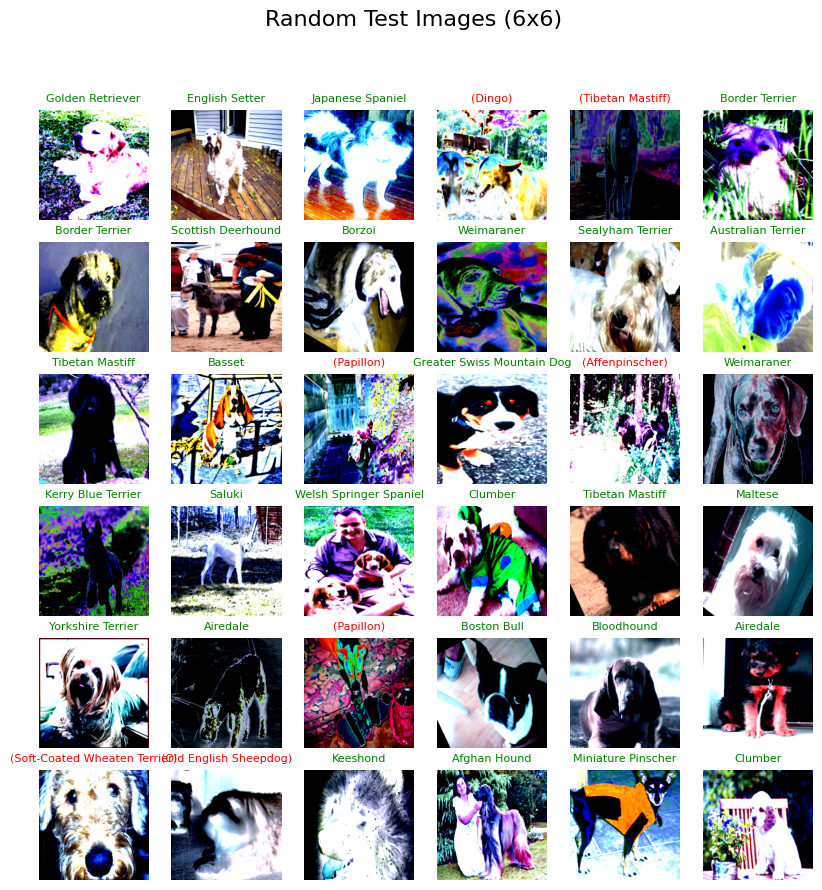

In [10]:
import random
import torchvision.models as models

# Create fresh data iterator to avoid StopIteration error
dataiter = iter(valloader)
images, labels = next(dataiter)

# Load our model (ResNet101)
net = models.resnet101(weights=None)
num_ftrs = net.fc.in_features
net.fc = nn.Linear(num_ftrs, 120)
net.load_state_dict(torch.load(PATH))

# Select 36 random samples from this batch
indices = random.sample(range(len(images)), 36)
images_36 = images[indices]
labels_36 = labels[indices]

# Analyze images
outputs = net(images_36)
_, predicted = torch.max(outputs, 1)
predicted = predicted.cpu()

# Display in 6x6 grid
num_rows, num_cols = 6, 6
plt.figure(figsize=(10, 10))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    img = images_36[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

    # Assign color based on whether prediction matches
    color = "green" if labels_36[i] == predicted[i] else "red"
    label_name = classes[predicted[i]] 
    if labels_36[i] != predicted[i]:
        label_name = "(" + label_name + ")"
    plt.title(label_name, color=color, fontsize=8)

plt.suptitle('Random Test Images (6x6)', fontsize=16)
plt.show()

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
with torch.no_grad():
    for data in tqdm(valloader, desc="TTA Evaluation"):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        
        # Use simple TTA for better predictions
        tta_outputs = test_time_augmentation_batch(net, images, num_augmentations=3)
        _, predictions = torch.max(tta_outputs, 1)
        
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label.item()]] += 1
            total_pred[classes[label.item()]] += 1

# Print accuracy statistics
per_class_acc = []
for classname, correct_count in correct_pred.items():
    total = total_pred[classname]
    if total == 0:
        continue
    else:
        accuracy = 100 * float(correct_count) / total
        per_class_acc.append(accuracy)
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

# Average per-class accuracy
avg_class_accuracy = np.mean(per_class_acc)
print(f'Average per-class accuracy: {avg_class_accuracy:.2f} %')

# Overall accuracy
total_correct = sum(correct_pred.values())
total_samples = sum(total_pred.values())
overall_accuracy = 100 * total_correct / total_samples
print(f'Overall testing accuracy: {overall_accuracy:.2f} %')

TTA Evaluation: 100%|██████████| 43/43 [02:05<00:00,  2.91s/it]

Accuracy for class: Affenpinscher is 77.8 %
Accuracy for class: Afghan Hound is 85.4 %
Accuracy for class: African Hunting Dog is 93.8 %
Accuracy for class: Airedale is 60.4 %
Accuracy for class: American Staffordshire Terrier is 52.9 %
Accuracy for class: Appenzeller is 65.5 %
Accuracy for class: Australian Terrier is 78.4 %
Accuracy for class: Basenji is 68.8 %
Accuracy for class: Basset is 80.0 %
Accuracy for class: Beagle is 79.5 %
Accuracy for class: Bedlington Terrier is 94.4 %
Accuracy for class: Bernese Mountain Dog is 81.8 %
Accuracy for class: Black and Tan Coonhound is 80.0 %
Accuracy for class: Blenheim Spaniel is 91.1 %
Accuracy for class: Bloodhound is 71.1 %
Accuracy for class: Bluetick is 77.1 %
Accuracy for class: Border Collie is 56.5 %
Accuracy for class: Border Terrier is 87.9 %
Accuracy for class: Borzoi is 77.1 %
Accuracy for class: Boston Bull is 78.9 %
Accuracy for class: Bouvier des Flandres is 78.3 %
Accuracy for class: Boxer is 51.5 %
Accuracy for class: Brab

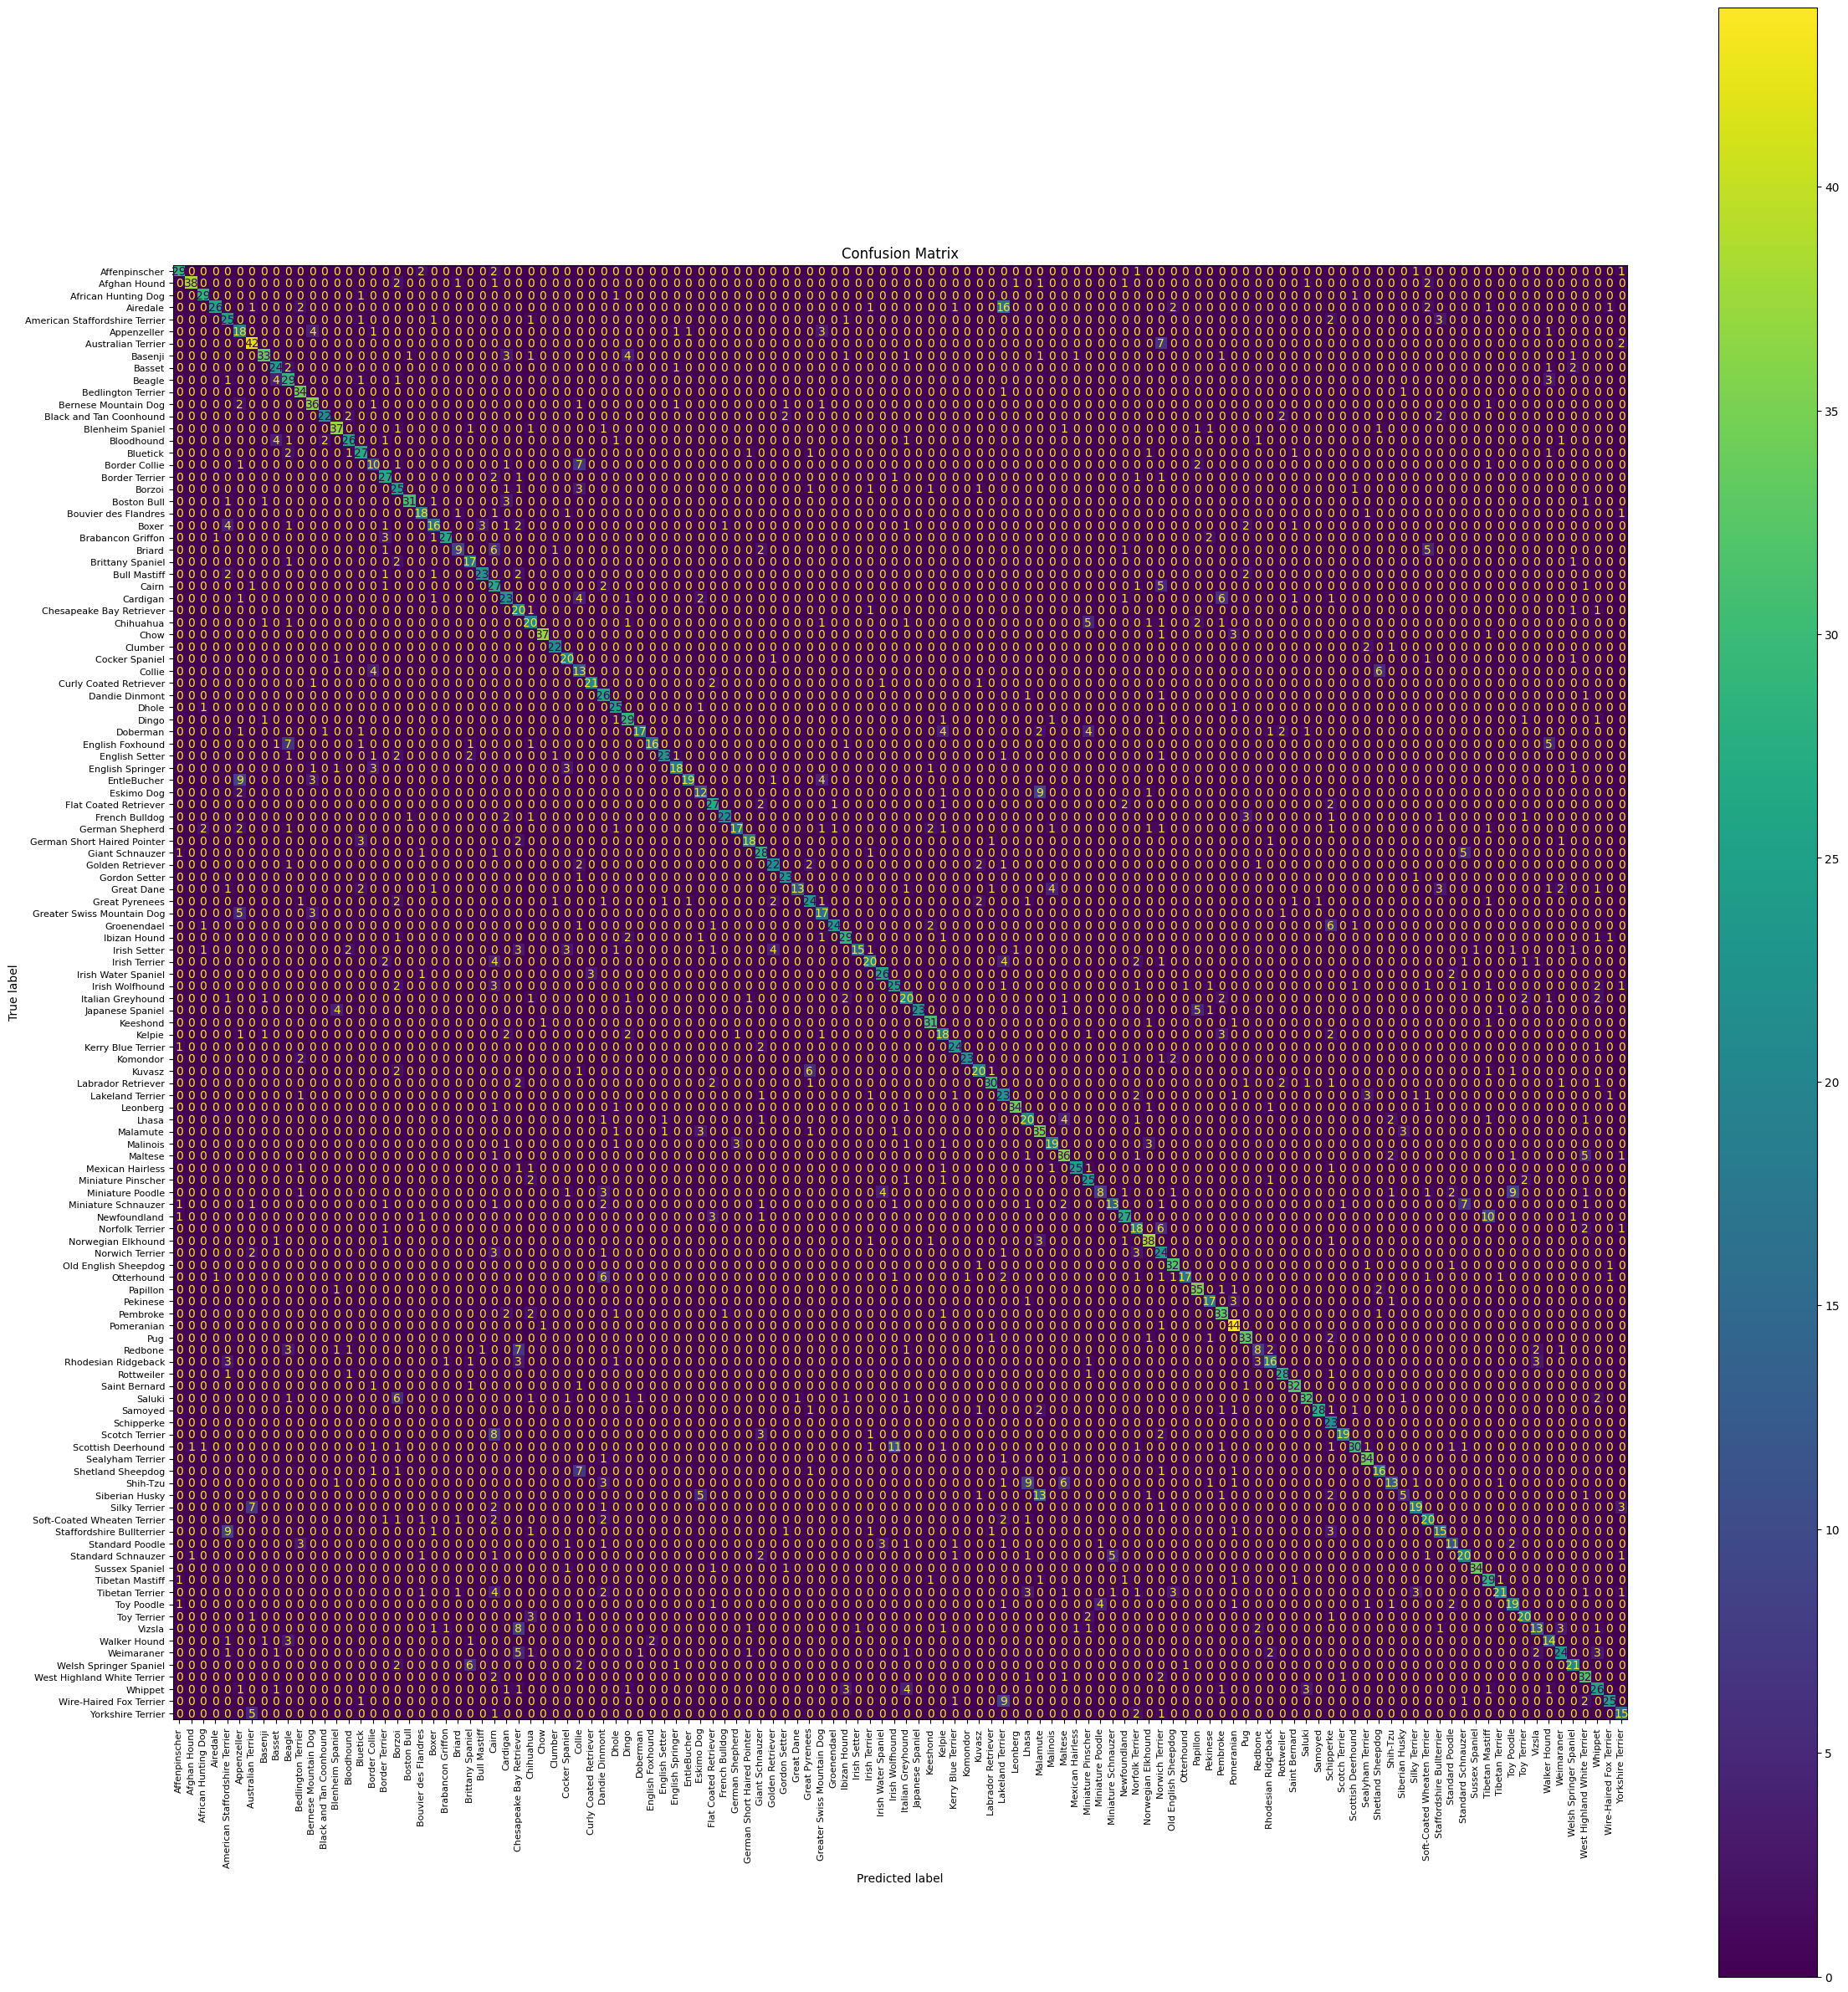

In [12]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_labels = []
all_preds = []

net.eval()
with torch.no_grad():
    for data in valloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(24, 24))
disp.plot(ax=ax, xticks_rotation=90)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()